In [11]:
import json
import os
import shutil
from PIL import Image
from tqdm import tqdm

# --- PLOTQA REMOVED ---
dataset_configs = [
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/train1", "split": "train"},
    {"name": "FigureQA", "base": "./../FigureQA_Dataset/validation1", "split": "val"}
]

CLASS_DOT = 0  

def process_dot_lines():
    print("🧹 Cleaning up old directories...")
    # Nuke the folder completely to clear out old mistakes
    if os.path.exists("./datasets/yolo_dataset_dots"):
        shutil.rmtree("./datasets/yolo_dataset_dots")
        
    for split in ['train', 'val']:
        os.makedirs(f"./datasets/yolo_dataset_dots/images/{split}", exist_ok=True)
        os.makedirs(f"./datasets/yolo_dataset_dots/labels/{split}", exist_ok=True)

    for config in dataset_configs:
        print(f"\nProcessing {config['name']} ({config['split']})...")
        anno_path = os.path.join(config['base'], "annotations.json")
        
        if not os.path.exists(anno_path): continue
            
        with open(anno_path, 'r') as f:
            data = json.load(f)
            
        for item in tqdm(data):
            # Strict check for dot-line type
            if item.get('type', '').lower() != 'dot_line':
                continue
                
            img_path = os.path.join(config['base'], "png", f"{item['image_index']}.png")
            if not os.path.exists(img_path): continue
                
            try:
                with Image.open(img_path) as img:
                    w_img, h_img = img.size
                
                yolo_lines = []
                
                for model in item.get('models', []):
                    # Filter out axis labels, titles, and legends
                    model_name = model.get('name', '')
                    if model_name is None: model_name = ''
                    model_name = model_name.lower()
                    
                    forbidden_words = ['axis', 'title', 'legend', 'label', 'background']
                    if any(word in model_name for word in forbidden_words):
                        continue
                        
                    if 'bboxes' in model:
                        for box in model['bboxes']:
                            if isinstance(box, dict):
                                x, y, w, h = box['x'], box['y'], box['w'], box['h']
                            else:
                                x, y, w, h = box
                                
                            # ==========================================
                            # 🛡️ THE GEOMETRIC SANITY FILTER 🛡️
                            # ==========================================
                            # A dot is a tiny square. If it's bigger than 50px, it's a bar/line. Toss it!
                            if w <= 0 or h <= 0 or w > 50 or h > 50: 
                                continue
                                
                            cx = (x + w / 2) / w_img
                            cy = (y + h / 2) / h_img
                            nw = w / w_img
                            nh = h / h_img
                            
                            yolo_lines.append(f"{CLASS_DOT} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}")

                # Only copy the image if we successfully extracted valid dots
                if yolo_lines:
                    base_name = f"{config['name']}_{item['image_index']}.png"
                    target_img_path = f"./datasets/yolo_dataset_dots/images/{config['split']}/{base_name}"
                    
                    shutil.copy(img_path, target_img_path)
                    
                    txt_filename = base_name.rsplit('.', 1)[0] + ".txt"
                    with open(f"./datasets/yolo_dataset_dots/labels/{config['split']}/{txt_filename}", 'w') as f:
                        f.write("\n".join(yolo_lines))
                        
            except Exception as e:
                pass

process_dot_lines()
print("\n✅ Pure FigureQA Dot-Line Dataset Generated!")

🧹 Cleaning up old directories...

Processing FigureQA (train)...


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 100000/100000 [00:09<00:00, 10198.10it/s]



Processing FigureQA (val)...


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20000/20000 [00:01<00:00, 11264.34it/s]



✅ Pure FigureQA Dot-Line Dataset Generated!


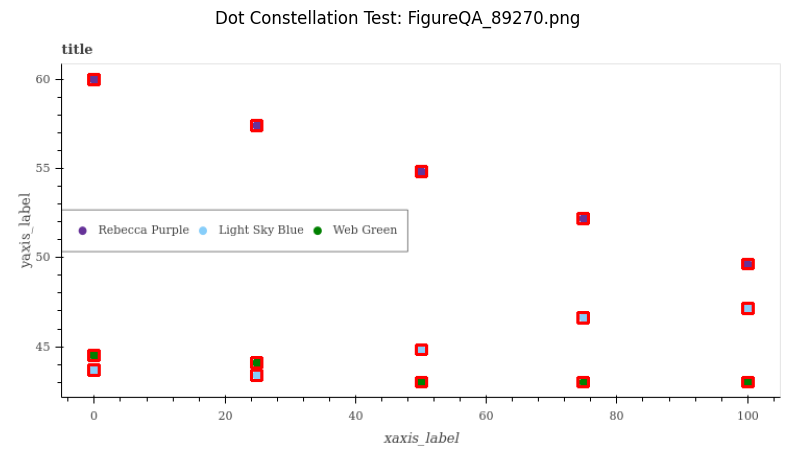

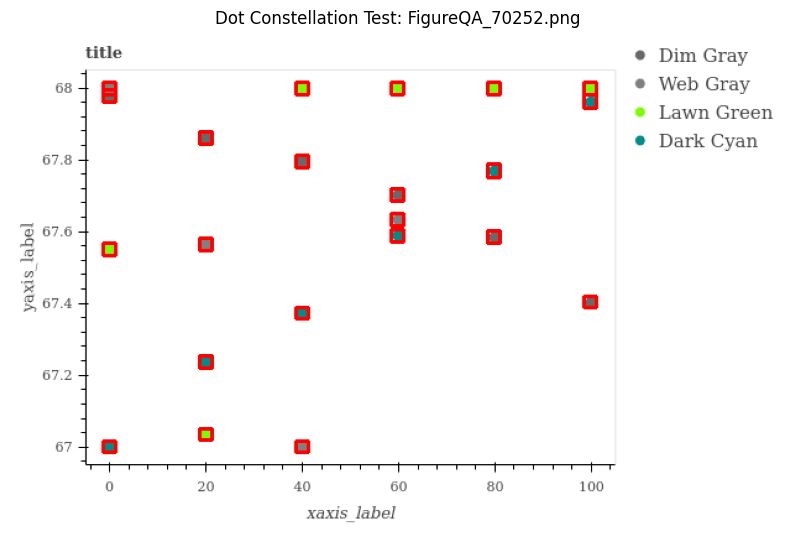

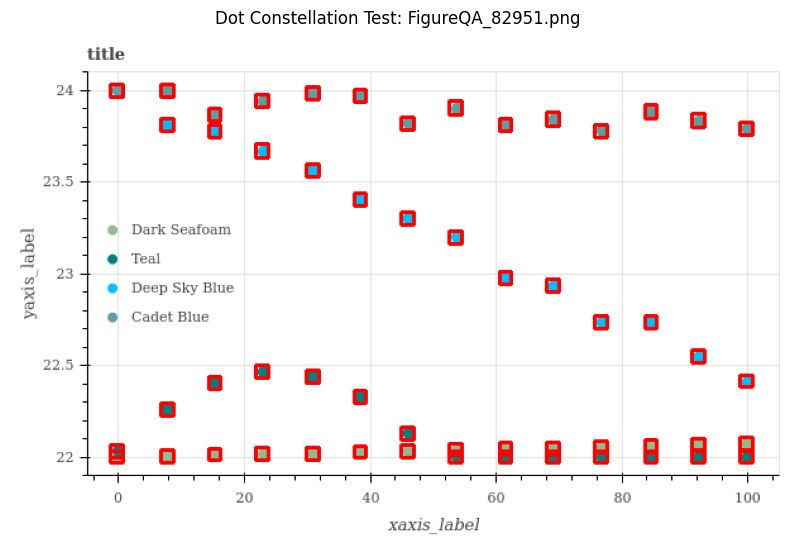

In [15]:
import cv2
import os
import random
import matplotlib.pyplot as plt

def test_dot_labels(img_dir, label_dir, num_samples=3):
    if not os.path.exists(img_dir) or not os.path.exists(label_dir):
        print("❌ Error: Dataset directories not found.")
        return
        
    images = [f for f in os.listdir(img_dir) if f.endswith(('.png', '.jpg'))]
    
    if not images:
        print("❌ No images found in the directory. The extraction might have failed.")
        return
    
    samples = random.sample(images, min(num_samples, len(images)))
    
    for sample_img in samples:
        sample_label = sample_img.rsplit('.', 1)[0] + '.txt'
        img_path = os.path.join(img_dir, sample_img)
        label_path = os.path.join(label_dir, sample_label)
        
        if not os.path.exists(label_path):
            continue

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w, _ = img.shape

        with open(label_path, 'r') as f:
            for line in f.readlines():
                parts = line.split()
                if len(parts) < 5: continue
                
                cx, cy, nw, nh = map(float, parts[1:5])
                
                x1 = int((cx - nw/2) * w)
                y1 = int((cy - nh/2) * h)
                x2 = int((cx + nw/2) * w)
                y2 = int((cy + nh/2) * h)
                
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        plt.figure(figsize=(10, 8))
        plt.imshow(img)
        plt.title(f"Dot Constellation Test: {sample_img}")
        plt.axis('off')
        plt.show()

# Pointing exactly to the newly created folders
images_path = './datasets/yolo_dataset_dots/images/train'
labels_path = './datasets/yolo_dataset_dots/labels/train'

test_dot_labels(images_path, labels_path, num_samples=3)

In [4]:
import cv2
import numpy as np
import easyocr
from ultralytics import YOLO
import matplotlib.pyplot as plt
import json
import re
import os
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

def extract_number(text_str):
    """Safely parse numbers from OCR text."""
    matches = re.findall(r'-?\d+\.?\d*', text_str.replace(',', ''))
    if matches:
        return float(matches[0])
    
    text_clean = text_str.strip().upper()
    if text_clean == 'O': return 0.0
    if text_clean == 'S': return 5.0
    if text_clean in ['I', 'L']: return 1.0
    return None

def color_distance(c1, c2):
    """Calculate Euclidean distance between two BGR colors."""
    return np.linalg.norm(np.array(c1, dtype=np.float32) - np.array(c2, dtype=np.float32))

def test_dot_extraction(image_path, yolo_model_path):
    print(f"🚀 Loading YOLO model from: {yolo_model_path}")
    
    if not os.path.exists(yolo_model_path):
        print(f"❌ ERROR: Model not found at {yolo_model_path}")
        return
        
    yolo_model = YOLO(yolo_model_path)
    ocr_reader = easyocr.Reader(['en'], gpu=True, verbose=False)

    print(f"📸 Analyzing image: {image_path}")
    
    # 1. Run YOLO to find dots
    results = yolo_model(image_path, conf=0.5, iou=0.4, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("❌ No dots detected by YOLO.")
        return

    # 2. Upscaled OCR Scanning
    img_cv = cv2.imread(image_path)
    img_upscaled = cv2.resize(img_cv, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    ocr_results = ocr_reader.readtext(img_upscaled)
    
    numbers = []
    text_labels = []
    raw_legend_candidates = []

    for (bbox, text, prob) in ocr_results:
        # Scale bounding box back down to original image coordinates
        orig_tl_x, orig_tl_y = bbox[0][0] / 2.0, bbox[0][1] / 2.0
        orig_br_x, orig_br_y = bbox[2][0] / 2.0, bbox[2][1] / 2.0
        
        cx = (orig_tl_x + orig_br_x) / 2.0
        cy = (orig_tl_y + orig_br_y) / 2.0
        
        val = extract_number(text)
        if val is not None:
            numbers.append({'val': val, 'x': cx, 'y': cy})
        else:
            text_labels.append({'text': text, 'x': cx, 'y': cy})
            # Save raw coordinates for color sampling later
            raw_legend_candidates.append({
                'text': text, 
                'x': cx,             # Fixed missing key here
                'tl_x': orig_tl_x, 
                'cy': cy, 
                'height': orig_br_y - orig_tl_y
            })

    # 3. Robust Axis Scaling (Using Linear Regression to ignore OCR typos)
    leftmost_dot = boxes[:, 0].min()
    bottommost_dot = boxes[:, 3].max()

    # Y-AXIS
    y_axis_nums = [n for n in numbers if n['x'] < leftmost_dot + 30]
    if len(y_axis_nums) >= 2:
        y_coords = [n['y'] for n in y_axis_nums]
        y_vals = [n['val'] for n in y_axis_nums]
        y_m, y_c = np.polyfit(y_coords, y_vals, 1)
    else:
        y_m, y_c = 1.0, 0.0

    # X-AXIS
    x_axis_nums = [n for n in numbers if n['y'] > bottommost_dot - 30]
    if len(x_axis_nums) >= 2:
        x_coords = [n['x'] for n in x_axis_nums]
        x_vals = [n['val'] for n in x_axis_nums]
        x_m, x_c = np.polyfit(x_coords, x_vals, 1)
    else:
        x_m, x_c = 1.0, 0.0

    # 4. Extract Colors from Legend
    legend_colors = {}
    ignore_words = ['xaxis_label', 'yaxis_label', 'xaxis label', 'yaxis label', 'title', 'x_axis', 'y_axis']
    
    # Filter to likely legend items (Right side of graph, not a title/axis label)
    for item in raw_legend_candidates:
        clean_text = item['text'].strip()
        if clean_text.lower() in ignore_words or item['x'] < leftmost_dot:
            continue
            
        # Sample the color slightly to the left of the legend text
        sample_x = int(item['tl_x'] - item['height']) 
        sample_y = int(item['cy'])
        
        # Ensure we don't go out of bounds
        if sample_x > 0 and sample_y > 0 and sample_x < img_cv.shape[1] and sample_y < img_cv.shape[0]:
            # OpenCV loads in BGR format
            bgr_color = img_cv[sample_y, sample_x]
            # Ignore white/gray backgrounds (sum of colors > 700 usually means white)
            if int(bgr_color[0]) + int(bgr_color[1]) + int(bgr_color[2]) < 700:
                legend_colors[clean_text] = bgr_color

    print(f"🎨 Detected {len(legend_colors)} Legend Classes: {list(legend_colors.keys())}")

    # 5. Map Dots to Real (X, Y) Coordinates & Colors
    extracted_points = []
    for box in boxes:
        cx = int((box[0] + box[2]) / 2)
        cy = int((box[1] + box[3]) / 2)
        
        # Apply the linear regression math
        real_x = (x_m * cx) + x_c
        real_y = (y_m * cy) + y_c
        
        # Sample dot color
        dot_color = img_cv[cy, cx]
        
        # Match to closest legend class
        best_class = "Unknown"
        if legend_colors:
            best_class = min(legend_colors.keys(), key=lambda k: color_distance(dot_color, legend_colors[k]))

        extracted_points.append({
            "class": best_class,
            "x": float(round(real_x, 2)), 
            "y": float(round(real_y, 2))
        })

    # Sort sequentially left to right
    extracted_points.sort(key=lambda p: p['x'])

    # 6. Extract Axis Labels
    title, x_axis_label, y_axis_label = None, None, None

    if text_labels:
        top_most = min(text_labels, key=lambda l: l['y'])
        if top_most['y'] < boxes[:, 1].min(): 
            title = top_most['text']
        
        remaining = [l for l in text_labels if l != top_most]
        if remaining:
            bottom_most = max(remaining, key=lambda l: l['y'])
            x_axis_label = bottom_most['text']
            left_most = min(remaining, key=lambda l: l['x'])
            y_axis_label = left_most['text']

    # --- FINAL JSON BUILD ---
    output = {
        "title": title,
        "x_axis_label": x_axis_label,
        "y_axis_label": y_axis_label,
        "total_points": len(extracted_points),
        "data": extracted_points
    }

    print("\n📈 Final Extracted JSON Output:")
    print(json.dumps(output, indent=4))
    
    return output



# ==========================================
# RUN THE TEST
# ==========================================
# 🚨 UPDATE THESE TWO PATHS 🚨
my_model_path = "dot_detector_run/weights/best.pt"
my_image_path = "./../FigureQA_Dataset/train1/png/85005.png"

results = test_dot_extraction(my_image_path, my_model_path)

🚀 Loading YOLO model from: dot_detector_run/weights/best.pt
📸 Analyzing image: ./../FigureQA_Dataset/train1/png/85005.png
🎨 Detected 7 Legend Classes: ['Light Coral', 'Burlywood', 'Magenta', 'Violet', 'Dark Cyan', 'Deep Pink', 'Dark Seafoam']

📈 Final Extracted JSON Output:
{
    "title": "title",
    "x_axis_label": "xaxis label",
    "y_axis_label": "xaxis label",
    "total_points": 78,
    "data": [
        {
            "class": "Dark Cyan",
            "x": 6.66,
            "y": 20.96
        },
        {
            "class": "Magenta",
            "x": 6.66,
            "y": 60.81
        },
        {
            "class": "Dark Seafoam",
            "x": 6.66,
            "y": 62.67
        },
        {
            "class": "Violet",
            "x": 6.66,
            "y": 13.5
        },
        {
            "class": "Dark Cyan",
            "x": 14.78,
            "y": 29.61
        },
        {
            "class": "Violet",
            "x": 14.78,
            "y": 16.39
  

🚀 Loading YOLO model from: dot_detector_run/weights/best.pt
📸 Analyzing image: ./../FigureQA_Dataset/train1/png/85005.png
🎨 Detected 7 Legend Classes: ['Light Coral', 'Burlywood', 'Magenta', 'Violet', 'Dark Cyan', 'Deep Pink', 'Dark Seafoam']


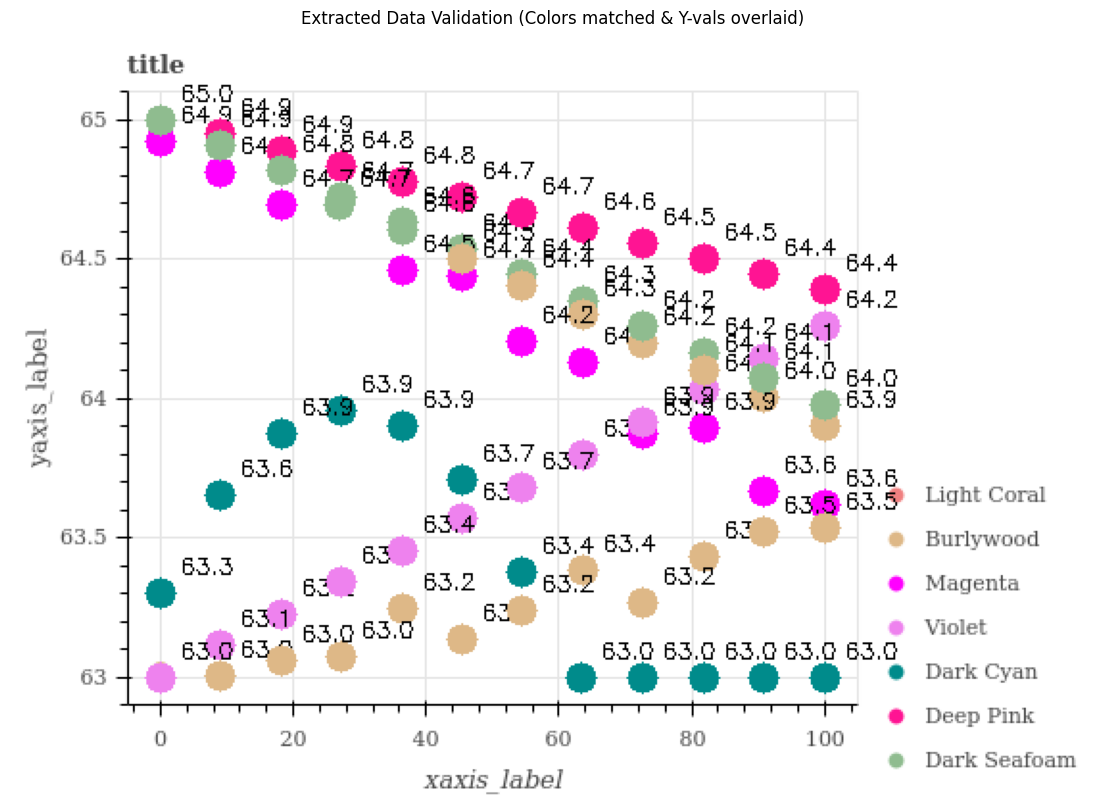


📈 Final Extracted JSON Output:
{
    "title": "title",
    "x_axis_label": "xaxis label",
    "y_axis_label": "xaxis label",
    "total_points": 78,
    "data": [
        {
            "class": "Dark Cyan",
            "x": -0.08,
            "y": 63.28
        },
        {
            "class": "Magenta",
            "x": -0.08,
            "y": 64.92
        },
        {
            "class": "Dark Seafoam",
            "x": -0.08,
            "y": 65.0
        },
        {
            "class": "Violet",
            "x": -0.08,
            "y": 62.97
        },
        {
            "class": "Dark Cyan",
            "x": 8.89,
            "y": 63.63
        },
        {
            "class": "Violet",
            "x": 8.89,
            "y": 63.09
        },
        {
            "class": "Magenta",
            "x": 8.89,
            "y": 64.81
        },
        {
            "class": "Burlywood",
            "x": 8.89,
            "y": 62.98
        },
        {
            "class": "

In [5]:
import cv2
import numpy as np
import easyocr
from ultralytics import YOLO
import matplotlib.pyplot as plt
import json
import re
import os
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

def extract_number(text_str):
    """Safely parse numbers from OCR text."""
    matches = re.findall(r'-?\d+\.?\d*', text_str.replace(',', ''))
    if matches:
        return float(matches[0])
    
    text_clean = text_str.strip().upper()
    if text_clean == 'O': return 0.0
    if text_clean == 'S': return 5.0
    if text_clean in ['I', 'L']: return 1.0
    return None

def color_distance(c1, c2):
    """Calculate Euclidean distance between two BGR colors."""
    return np.linalg.norm(np.array(c1, dtype=np.float32) - np.array(c2, dtype=np.float32))

def get_robust_scale(axis_nums, axis_key='y'):
    """
    Robust scaling that ignores OCR typos (like reading 64.5 as 645).
    Calculates slopes between all pairs and takes the median to reject outliers.
    """
    if len(axis_nums) < 2:
        return 1.0, 0.0

    coords = np.array([n[axis_key] for n in axis_nums])
    vals = np.array([n['val'] for n in axis_nums])

    # Try to fix obvious missing decimals (if a value is >10x the median)
    median_val = np.median(vals)
    if median_val > 0:
        for i in range(len(vals)):
            if vals[i] > median_val * 5: 
                vals[i] /= 10.0

    slopes = []
    for i in range(len(coords)):
        for j in range(i+1, len(coords)):
            # Avoid division by zero if pixels are too close
            if abs(coords[i] - coords[j]) > 10: 
                slope = (vals[i] - vals[j]) / (coords[i] - coords[j])
                slopes.append(slope)
    
    if not slopes:
        return 1.0, 0.0
        
    best_m = np.median(slopes)
    intercepts = vals - best_m * coords
    best_c = np.median(intercepts)
    
    return best_m, best_c


def test_dot_extraction(image_path, yolo_model_path):
    print(f"🚀 Loading YOLO model from: {yolo_model_path}")
    
    if not os.path.exists(yolo_model_path):
        print(f"❌ ERROR: Model not found at {yolo_model_path}")
        return
        
    yolo_model = YOLO(yolo_model_path)
    ocr_reader = easyocr.Reader(['en'], gpu=True, verbose=False)

    print(f"📸 Analyzing image: {image_path}")
    
    # 1. Run YOLO to find dots
    results = yolo_model(image_path, conf=0.5, iou=0.4, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("❌ No dots detected by YOLO.")
        return

    # 2. Upscaled OCR Scanning
    img_cv = cv2.imread(image_path)
    img_upscaled = cv2.resize(img_cv, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    ocr_results = ocr_reader.readtext(img_upscaled)
    
    numbers = []
    text_labels = []
    raw_legend_candidates = []

    for (bbox, text, prob) in ocr_results:
        orig_tl_x, orig_tl_y = bbox[0][0] / 2.0, bbox[0][1] / 2.0
        orig_br_x, orig_br_y = bbox[2][0] / 2.0, bbox[2][1] / 2.0
        
        cx = (orig_tl_x + orig_br_x) / 2.0
        cy = (orig_tl_y + orig_br_y) / 2.0
        
        val = extract_number(text)
        if val is not None:
            numbers.append({'val': val, 'x': cx, 'y': cy})
        else:
            text_labels.append({'text': text, 'x': cx, 'y': cy})
            raw_legend_candidates.append({
                'text': text, 
                'x': cx,
                'tl_x': orig_tl_x, 
                'cy': cy, 
                'height': orig_br_y - orig_tl_y
            })

    # 3. Robust Axis Scaling
    leftmost_dot = boxes[:, 0].min()
    bottommost_dot = boxes[:, 3].max()

    # Isolate numbers strictly on the left axis (X < leftmost dot)
    y_axis_nums = [n for n in numbers if n['x'] < leftmost_dot]
    y_m, y_c = get_robust_scale(y_axis_nums, axis_key='y')

    # Isolate numbers strictly on the bottom axis (Y > bottommost dot)
    x_axis_nums = [n for n in numbers if n['y'] > bottommost_dot]
    x_m, x_c = get_robust_scale(x_axis_nums, axis_key='x')

    # 4. Extract Colors from Legend
    legend_colors = {}
    ignore_words = ['xaxis_label', 'yaxis_label', 'xaxis label', 'yaxis label', 'title', 'x_axis', 'y_axis']
    
    for item in raw_legend_candidates:
        clean_text = item['text'].strip()
        # Only look at text far to the right (past the middle of the image)
        if clean_text.lower() in ignore_words or item['x'] < (img_cv.shape[1] * 0.7):
            continue
            
        sample_x = int(item['tl_x'] - item['height']) 
        sample_y = int(item['cy'])
        
        if sample_x > 0 and sample_y > 0 and sample_x < img_cv.shape[1] and sample_y < img_cv.shape[0]:
            bgr_color = img_cv[sample_y, sample_x]
            # Ignore backgrounds (white/gray)
            if int(bgr_color[0]) + int(bgr_color[1]) + int(bgr_color[2]) < 700:
                legend_colors[clean_text] = bgr_color

    print(f"🎨 Detected {len(legend_colors)} Legend Classes: {list(legend_colors.keys())}")

    # 5. Map Dots to Real (X, Y) Coordinates & Colors
    extracted_points = []
    
    # Image for visualization
    vis_img = cv2.cvtColor(img_cv.copy(), cv2.COLOR_BGR2RGB)

    for box in boxes:
        cx = int((box[0] + box[2]) / 2)
        cy = int((box[1] + box[3]) / 2)
        
        # Apply the robust math
        real_x = (x_m * cx) + x_c
        real_y = (y_m * cy) + y_c
        
        # Sample dot color and find best class
        dot_color = img_cv[cy, cx]
        best_class = "Unknown"
        best_color_rgb = (0, 0, 0)
        
        if legend_colors:
            best_class = min(legend_colors.keys(), key=lambda k: color_distance(dot_color, legend_colors[k]))
            # Convert BGR back to RGB for matplotlib drawing
            b, g, r = legend_colors[best_class]
            best_color_rgb = (int(r), int(g), int(b))

        # Save to list
        extracted_points.append({
            "class": best_class,
            "x": float(round(real_x, 2)), 
            "y": float(round(real_y, 2))
        })
        
        # Draw on visualization image
        cv2.circle(vis_img, (cx, cy), radius=8, color=best_color_rgb, thickness=-1)
        cv2.putText(vis_img, f"{real_y:.1f}", (cx + 10, cy - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

    # Sort sequentially left to right
    extracted_points.sort(key=lambda p: p['x'])

    # 6. Extract Axis Labels
    title, x_axis_label, y_axis_label = None, None, None

    if text_labels:
        top_most = min(text_labels, key=lambda l: l['y'])
        if top_most['y'] < boxes[:, 1].min(): 
            title = top_most['text']
        
        remaining = [l for l in text_labels if l != top_most]
        if remaining:
            bottom_most = max(remaining, key=lambda l: l['y'])
            x_axis_label = bottom_most['text']
            left_most = min(remaining, key=lambda l: l['x'])
            y_axis_label = left_most['text']

    # --- FINAL DISPLAY & OUTPUT ---
    plt.figure(figsize=(14, 10))
    plt.imshow(vis_img)
    plt.title("Extracted Data Validation (Colors matched & Y-vals overlaid)")
    plt.axis('off')
    plt.show()

    output = {
        "title": title,
        "x_axis_label": x_axis_label,
        "y_axis_label": y_axis_label,
        "total_points": len(extracted_points),
        "data": extracted_points
    }

    print("\n📈 Final Extracted JSON Output:")
    print(json.dumps(output, indent=4))
    
    return output

# ==========================================
# RUN THE TEST
# ==========================================
# 🚨 UPDATE THESE TWO PATHS 🚨
my_model_path = "dot_detector_run/weights/best.pt"
my_image_path = "./../FigureQA_Dataset/train1/png/85005.png"

results = test_dot_extraction(my_image_path, my_model_path)

🚀 Loading YOLO model from: dot_detector_run/weights/best.pt
📸 Analyzing image: ./../FigureQA_Dataset/train1/png/85007.png
🎨 Detected 6 Legend Classes: ['Medium Periwinkle', 'Salmon', 'Medium Mint', 'Sienna', 'Black', 'Lawn Green']


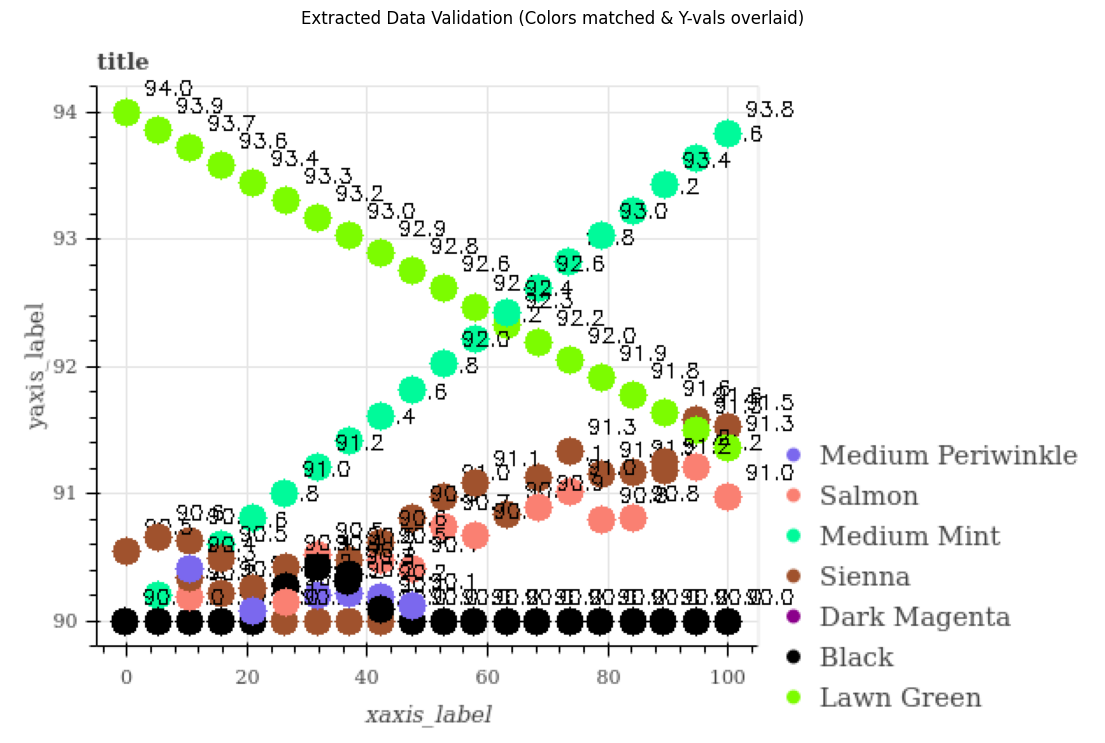


📈 Final Extracted JSON Output:
{
    "title": "title",
    "x_axis_label": "xaxis label",
    "y_axis_label": "xaxis label",
    "total_points": 104,
    "data": [
        {
            "class": "Black",
            "x": -0.58,
            "y": 89.97
        },
        {
            "class": "Lawn Green",
            "x": -0.29,
            "y": 94.0
        },
        {
            "class": "Sienna",
            "x": -0.29,
            "y": 90.53
        },
        {
            "class": "Lawn Green",
            "x": 4.96,
            "y": 93.86
        },
        {
            "class": "Medium Mint",
            "x": 4.96,
            "y": 90.18
        },
        {
            "class": "Sienna",
            "x": 4.96,
            "y": 90.64
        },
        {
            "class": "Black",
            "x": 4.96,
            "y": 89.97
        },
        {
            "class": "Lawn Green",
            "x": 10.22,
            "y": 93.72
        },
        {
            "class": "S

In [7]:
import cv2
import numpy as np
import easyocr
from ultralytics import YOLO
import matplotlib.pyplot as plt
import json
import re
import os
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

def extract_number(text_str):
    """Safely parse numbers from OCR text."""
    matches = re.findall(r'-?\d+\.?\d*', text_str.replace(',', ''))
    if matches:
        return float(matches[0])
    
    text_clean = text_str.strip().upper()
    if text_clean == 'O': return 0.0
    if text_clean == 'S': return 5.0
    if text_clean in ['I', 'L']: return 1.0
    return None

def color_distance(c1, c2):
    """Calculate Euclidean distance between two BGR colors."""
    return np.linalg.norm(np.array(c1, dtype=np.float32) - np.array(c2, dtype=np.float32))

def get_robust_scale(axis_nums, axis_key='y'):
    """
    Robust scaling that ignores OCR typos (like reading 64.5 as 645).
    Calculates slopes between all pairs and takes the median to reject outliers.
    """
    if len(axis_nums) < 2:
        return 1.0, 0.0

    coords = np.array([n[axis_key] for n in axis_nums])
    vals = np.array([n['val'] for n in axis_nums])

    # Try to fix obvious missing decimals (if a value is >10x the median)
    median_val = np.median(vals)
    if median_val > 0:
        for i in range(len(vals)):
            if vals[i] > median_val * 5: 
                vals[i] /= 10.0

    slopes = []
    for i in range(len(coords)):
        for j in range(i+1, len(coords)):
            # Avoid division by zero if pixels are too close
            if abs(coords[i] - coords[j]) > 10: 
                slope = (vals[i] - vals[j]) / (coords[i] - coords[j])
                slopes.append(slope)
    
    if not slopes:
        return 1.0, 0.0
        
    best_m = np.median(slopes)
    intercepts = vals - best_m * coords
    best_c = np.median(intercepts)
    
    return best_m, best_c


def test_dot_extraction(image_path, yolo_model_path):
    print(f"🚀 Loading YOLO model from: {yolo_model_path}")
    
    if not os.path.exists(yolo_model_path):
        print(f"❌ ERROR: Model not found at {yolo_model_path}")
        return
        
    yolo_model = YOLO(yolo_model_path)
    ocr_reader = easyocr.Reader(['en'], gpu=True, verbose=False)

    print(f"📸 Analyzing image: {image_path}")
    
    # 1. Run YOLO to find dots
    results = yolo_model(image_path, conf=0.5, iou=0.4, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("❌ No dots detected by YOLO.")
        return

    # 2. Upscaled OCR Scanning
    img_cv = cv2.imread(image_path)
    img_upscaled = cv2.resize(img_cv, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    ocr_results = ocr_reader.readtext(img_upscaled)
    
    numbers = []
    text_labels = []
    raw_legend_candidates = []

    for (bbox, text, prob) in ocr_results:
        orig_tl_x, orig_tl_y = bbox[0][0] / 2.0, bbox[0][1] / 2.0
        orig_br_x, orig_br_y = bbox[2][0] / 2.0, bbox[2][1] / 2.0
        
        cx = (orig_tl_x + orig_br_x) / 2.0
        cy = (orig_tl_y + orig_br_y) / 2.0
        
        val = extract_number(text)
        if val is not None:
            numbers.append({'val': val, 'x': cx, 'y': cy})
        else:
            text_labels.append({'text': text, 'x': cx, 'y': cy})
            raw_legend_candidates.append({
                'text': text, 
                'x': cx,
                'tl_x': orig_tl_x, 
                'cy': cy, 
                'height': orig_br_y - orig_tl_y
            })

    # 3. Robust Axis Scaling
    leftmost_dot = boxes[:, 0].min()
    bottommost_dot = boxes[:, 3].max()

    # Isolate numbers strictly on the left axis (X < leftmost dot)
    y_axis_nums = [n for n in numbers if n['x'] < leftmost_dot]
    y_m, y_c = get_robust_scale(y_axis_nums, axis_key='y')

    # Isolate numbers strictly on the bottom axis (Y > bottommost dot)
    x_axis_nums = [n for n in numbers if n['y'] > bottommost_dot]
    x_m, x_c = get_robust_scale(x_axis_nums, axis_key='x')

    # 4. Extract Colors from Legend
    legend_colors = {}
    ignore_words = ['xaxis_label', 'yaxis_label', 'xaxis label', 'yaxis label', 'title', 'x_axis', 'y_axis']
    
    for item in raw_legend_candidates:
        clean_text = item['text'].strip()
        # Only look at text far to the right (past the middle of the image)
        if clean_text.lower() in ignore_words or item['x'] < (img_cv.shape[1] * 0.7):
            continue
            
        sample_x = int(item['tl_x'] - item['height']) 
        sample_y = int(item['cy'])
        
        if sample_x > 0 and sample_y > 0 and sample_x < img_cv.shape[1] and sample_y < img_cv.shape[0]:
            bgr_color = img_cv[sample_y, sample_x]
            # Ignore backgrounds (white/gray)
            if int(bgr_color[0]) + int(bgr_color[1]) + int(bgr_color[2]) < 700:
                legend_colors[clean_text] = bgr_color

    print(f"🎨 Detected {len(legend_colors)} Legend Classes: {list(legend_colors.keys())}")

    # 5. Map Dots to Real (X, Y) Coordinates & Colors
    extracted_points = []
    
    # Image for visualization
    vis_img = cv2.cvtColor(img_cv.copy(), cv2.COLOR_BGR2RGB)

    for box in boxes:
        cx = int((box[0] + box[2]) / 2)
        cy = int((box[1] + box[3]) / 2)
        
        # Apply the robust math
        real_x = (x_m * cx) + x_c
        real_y = (y_m * cy) + y_c
        
        # Sample dot color and find best class
        dot_color = img_cv[cy, cx]
        best_class = "Unknown"
        best_color_rgb = (0, 0, 0)
        
        if legend_colors:
            best_class = min(legend_colors.keys(), key=lambda k: color_distance(dot_color, legend_colors[k]))
            # Convert BGR back to RGB for matplotlib drawing
            b, g, r = legend_colors[best_class]
            best_color_rgb = (int(r), int(g), int(b))

        # Save to list
        extracted_points.append({
            "class": best_class,
            "x": float(round(real_x, 2)), 
            "y": float(round(real_y, 2))
        })
        
        # Draw on visualization image
        cv2.circle(vis_img, (cx, cy), radius=8, color=best_color_rgb, thickness=-1)
        cv2.putText(vis_img, f"{real_y:.1f}", (cx + 10, cy - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

    # Sort sequentially left to right
    extracted_points.sort(key=lambda p: p['x'])

    # 6. Extract Axis Labels
    title, x_axis_label, y_axis_label = None, None, None

    if text_labels:
        top_most = min(text_labels, key=lambda l: l['y'])
        if top_most['y'] < boxes[:, 1].min(): 
            title = top_most['text']
        
        remaining = [l for l in text_labels if l != top_most]
        if remaining:
            bottom_most = max(remaining, key=lambda l: l['y'])
            x_axis_label = bottom_most['text']
            left_most = min(remaining, key=lambda l: l['x'])
            y_axis_label = left_most['text']

    # --- FINAL DISPLAY & OUTPUT ---
    plt.figure(figsize=(14, 10))
    plt.imshow(vis_img)
    plt.title("Extracted Data Validation (Colors matched & Y-vals overlaid)")
    plt.axis('off')
    plt.show()

    output = {
        "title": title,
        "x_axis_label": x_axis_label,
        "y_axis_label": y_axis_label,
        "total_points": len(extracted_points),
        "data": extracted_points
    }

    print("\n📈 Final Extracted JSON Output:")
    print(json.dumps(output, indent=4))
    
    return output

# ==========================================
# RUN THE TEST
# ==========================================
# 🚨 UPDATE THESE TWO PATHS 🚨
my_model_path = "dot_detector_run/weights/best.pt"
my_image_path = "./../FigureQA_Dataset/train1/png/85007.png"

results = test_dot_extraction(my_image_path, my_model_path)

🚀 Loading YOLO model from: dot_detector_run/weights/best.pt
📸 Analyzing image: ./../FigureQA_Dataset/train1/png/85004.png
🎨 Detected 0 Legend Classes: []


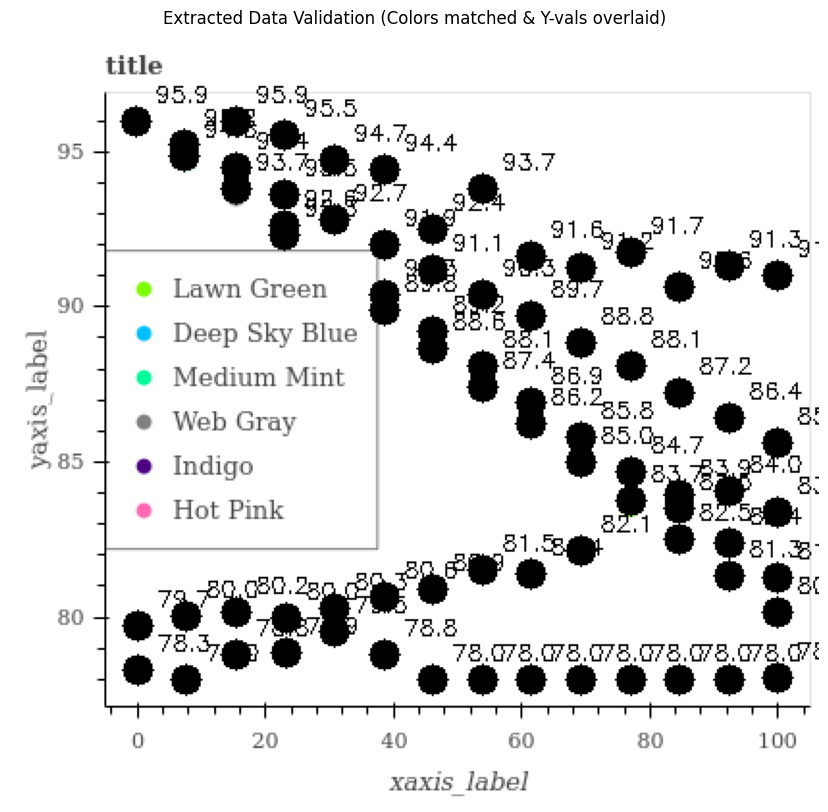


📈 Final Extracted JSON Output:
{
    "title": "title",
    "x_axis_label": "xaxis label",
    "y_axis_label": "Deep",
    "total_points": 75,
    "data": [
        {
            "class": "Unknown",
            "x": -0.36,
            "y": 95.9
        },
        {
            "class": "Unknown",
            "x": -0.06,
            "y": 79.72
        },
        {
            "class": "Unknown",
            "x": -0.06,
            "y": 78.3
        },
        {
            "class": "Unknown",
            "x": 7.17,
            "y": 95.15
        },
        {
            "class": "Unknown",
            "x": 7.17,
            "y": 94.78
        },
        {
            "class": "Unknown",
            "x": 7.47,
            "y": 77.99
        },
        {
            "class": "Unknown",
            "x": 7.47,
            "y": 80.03
        },
        {
            "class": "Unknown",
            "x": 15.3,
            "y": 80.15
        },
        {
            "class": "Unknown",
        

In [1]:
import cv2
import numpy as np
import easyocr
from ultralytics import YOLO
import matplotlib.pyplot as plt
import json
import re
import os
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

def extract_number(text_str):
    """Safely parse numbers from OCR text."""
    matches = re.findall(r'-?\d+\.?\d*', text_str.replace(',', ''))
    if matches:
        return float(matches[0])
    
    text_clean = text_str.strip().upper()
    if text_clean == 'O': return 0.0
    if text_clean == 'S': return 5.0
    if text_clean in ['I', 'L']: return 1.0
    return None

def color_distance(c1, c2):
    """Calculate Euclidean distance between two BGR colors."""
    return np.linalg.norm(np.array(c1, dtype=np.float32) - np.array(c2, dtype=np.float32))

def get_robust_scale(axis_nums, axis_key='y'):
    """
    Robust scaling that ignores OCR typos (like reading 64.5 as 645).
    Calculates slopes between all pairs and takes the median to reject outliers.
    """
    if len(axis_nums) < 2:
        return 1.0, 0.0

    coords = np.array([n[axis_key] for n in axis_nums])
    vals = np.array([n['val'] for n in axis_nums])

    # Try to fix obvious missing decimals (if a value is >10x the median)
    median_val = np.median(vals)
    if median_val > 0:
        for i in range(len(vals)):
            if vals[i] > median_val * 5: 
                vals[i] /= 10.0

    slopes = []
    for i in range(len(coords)):
        for j in range(i+1, len(coords)):
            # Avoid division by zero if pixels are too close
            if abs(coords[i] - coords[j]) > 10: 
                slope = (vals[i] - vals[j]) / (coords[i] - coords[j])
                slopes.append(slope)
    
    if not slopes:
        return 1.0, 0.0
        
    best_m = np.median(slopes)
    intercepts = vals - best_m * coords
    best_c = np.median(intercepts)
    
    return best_m, best_c


def test_dot_extraction(image_path, yolo_model_path):
    print(f"🚀 Loading YOLO model from: {yolo_model_path}")
    
    if not os.path.exists(yolo_model_path):
        print(f"❌ ERROR: Model not found at {yolo_model_path}")
        return
        
    yolo_model = YOLO(yolo_model_path)
    ocr_reader = easyocr.Reader(['en'], gpu=True, verbose=False)

    print(f"📸 Analyzing image: {image_path}")
    
    # 1. Run YOLO to find dots
    results = yolo_model(image_path, conf=0.5, iou=0.4, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("❌ No dots detected by YOLO.")
        return

    # 2. Upscaled OCR Scanning
    img_cv = cv2.imread(image_path)
    img_upscaled = cv2.resize(img_cv, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    ocr_results = ocr_reader.readtext(img_upscaled)
    
    numbers = []
    text_labels = []
    raw_legend_candidates = []

    for (bbox, text, prob) in ocr_results:
        orig_tl_x, orig_tl_y = bbox[0][0] / 2.0, bbox[0][1] / 2.0
        orig_br_x, orig_br_y = bbox[2][0] / 2.0, bbox[2][1] / 2.0
        
        cx = (orig_tl_x + orig_br_x) / 2.0
        cy = (orig_tl_y + orig_br_y) / 2.0
        
        val = extract_number(text)
        if val is not None:
            numbers.append({'val': val, 'x': cx, 'y': cy})
        else:
            text_labels.append({'text': text, 'x': cx, 'y': cy})
            raw_legend_candidates.append({
                'text': text, 
                'x': cx,
                'tl_x': orig_tl_x, 
                'cy': cy, 
                'height': orig_br_y - orig_tl_y
            })

    # 3. Robust Axis Scaling
    leftmost_dot = boxes[:, 0].min()
    bottommost_dot = boxes[:, 3].max()

    # Isolate numbers strictly on the left axis (X < leftmost dot)
    y_axis_nums = [n for n in numbers if n['x'] < leftmost_dot]
    y_m, y_c = get_robust_scale(y_axis_nums, axis_key='y')

    # Isolate numbers strictly on the bottom axis (Y > bottommost dot)
    x_axis_nums = [n for n in numbers if n['y'] > bottommost_dot]
    x_m, x_c = get_robust_scale(x_axis_nums, axis_key='x')

    # 4. Extract Colors from Legend
    legend_colors = {}
    ignore_words = ['xaxis_label', 'yaxis_label', 'xaxis label', 'yaxis label', 'title', 'x_axis', 'y_axis']
    
    for item in raw_legend_candidates:
        clean_text = item['text'].strip()
        # Only look at text far to the right (past the middle of the image)
        if clean_text.lower() in ignore_words or item['x'] < (img_cv.shape[1] * 0.7):
            continue
            
        sample_x = int(item['tl_x'] - item['height']) 
        sample_y = int(item['cy'])
        
        if sample_x > 0 and sample_y > 0 and sample_x < img_cv.shape[1] and sample_y < img_cv.shape[0]:
            bgr_color = img_cv[sample_y, sample_x]
            # Ignore backgrounds (white/gray)
            if int(bgr_color[0]) + int(bgr_color[1]) + int(bgr_color[2]) < 700:
                legend_colors[clean_text] = bgr_color

    print(f"🎨 Detected {len(legend_colors)} Legend Classes: {list(legend_colors.keys())}")

    # 5. Map Dots to Real (X, Y) Coordinates & Colors
    extracted_points = []
    
    # Image for visualization
    vis_img = cv2.cvtColor(img_cv.copy(), cv2.COLOR_BGR2RGB)

    for box in boxes:
        cx = int((box[0] + box[2]) / 2)
        cy = int((box[1] + box[3]) / 2)
        
        # Apply the robust math
        real_x = (x_m * cx) + x_c
        real_y = (y_m * cy) + y_c
        
        # Sample dot color and find best class
        dot_color = img_cv[cy, cx]
        best_class = "Unknown"
        best_color_rgb = (0, 0, 0)
        
        if legend_colors:
            best_class = min(legend_colors.keys(), key=lambda k: color_distance(dot_color, legend_colors[k]))
            # Convert BGR back to RGB for matplotlib drawing
            b, g, r = legend_colors[best_class]
            best_color_rgb = (int(r), int(g), int(b))

        # Save to list
        extracted_points.append({
            "class": best_class,
            "x": float(round(real_x, 2)), 
            "y": float(round(real_y, 2))
        })
        
        # Draw on visualization image
        cv2.circle(vis_img, (cx, cy), radius=8, color=best_color_rgb, thickness=-1)
        cv2.putText(vis_img, f"{real_y:.1f}", (cx + 10, cy - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

    # Sort sequentially left to right
    extracted_points.sort(key=lambda p: p['x'])

    # 6. Extract Axis Labels
    title, x_axis_label, y_axis_label = None, None, None

    if text_labels:
        top_most = min(text_labels, key=lambda l: l['y'])
        if top_most['y'] < boxes[:, 1].min(): 
            title = top_most['text']
        
        remaining = [l for l in text_labels if l != top_most]
        if remaining:
            bottom_most = max(remaining, key=lambda l: l['y'])
            x_axis_label = bottom_most['text']
            left_most = min(remaining, key=lambda l: l['x'])
            y_axis_label = left_most['text']

    # --- FINAL DISPLAY & OUTPUT ---
    plt.figure(figsize=(14, 10))
    plt.imshow(vis_img)
    plt.title("Extracted Data Validation (Colors matched & Y-vals overlaid)")
    plt.axis('off')
    plt.show()

    output = {
        "title": title,
        "x_axis_label": x_axis_label,
        "y_axis_label": y_axis_label,
        "total_points": len(extracted_points),
        "data": extracted_points
    }

    print("\n📈 Final Extracted JSON Output:")
    print(json.dumps(output, indent=4))
    
    return output

# ==========================================
# RUN THE TEST
# ==========================================
# 🚨 UPDATE THESE TWO PATHS 🚨
my_model_path = "dot_detector_run/weights/best.pt"
my_image_path = "./../FigureQA_Dataset/train1/png/85004.png"

results = test_dot_extraction(my_image_path, my_model_path)

🚀 Loading YOLO model from: dot_detector_run/weights/best.pt
📸 Analyzing image: ./../FigureQA_Dataset/train1/png/85004.png
🎨 Detected 5 Legend Classes: ['Lawn Green', 'Deep', 'Medium Mint', 'Indigo', 'Hot Pink']


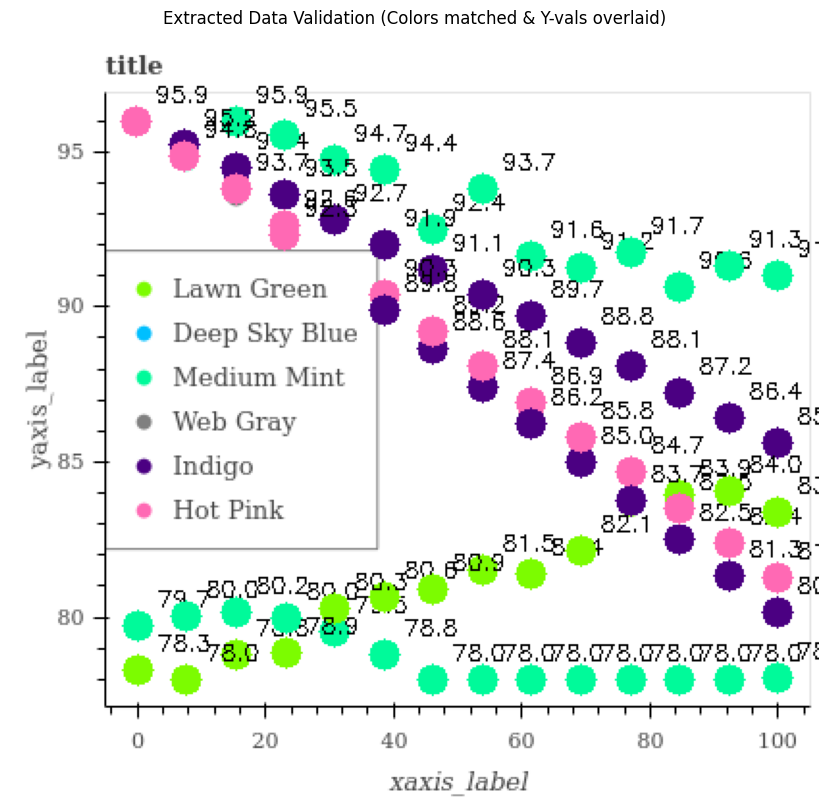


📈 Final Extracted JSON Output:
{
    "title": "title",
    "x_axis_label": "xaxis label",
    "y_axis_label": "Web Gray",
    "total_points": 75,
    "data": [
        {
            "class": "Hot Pink",
            "x": -0.36,
            "y": 95.9
        },
        {
            "class": "Medium Mint",
            "x": -0.06,
            "y": 79.72
        },
        {
            "class": "Lawn Green",
            "x": -0.06,
            "y": 78.3
        },
        {
            "class": "Indigo",
            "x": 7.17,
            "y": 95.15
        },
        {
            "class": "Hot Pink",
            "x": 7.17,
            "y": 94.78
        },
        {
            "class": "Lawn Green",
            "x": 7.47,
            "y": 77.99
        },
        {
            "class": "Medium Mint",
            "x": 7.47,
            "y": 80.03
        },
        {
            "class": "Medium Mint",
            "x": 15.3,
            "y": 80.15
        },
        {
            "clas

In [3]:
import cv2
import numpy as np
import easyocr
from ultralytics import YOLO
import matplotlib.pyplot as plt
import json
import re
import os
import warnings

# Suppress warnings for clean output
warnings.filterwarnings("ignore")

def extract_number(text_str):
    """Safely parse numbers from OCR text."""
    matches = re.findall(r'-?\d+\.?\d*', text_str.replace(',', ''))
    if matches:
        return float(matches[0])
    
    text_clean = text_str.strip().upper()
    if text_clean == 'O': return 0.0
    if text_clean == 'S': return 5.0
    if text_clean in ['I', 'L']: return 1.0
    return None

def color_distance(c1, c2):
    """Calculate Euclidean distance between two BGR colors."""
    return np.linalg.norm(np.array(c1, dtype=np.float32) - np.array(c2, dtype=np.float32))

def get_robust_scale(axis_nums, axis_key='y'):
    """
    Robust scaling that ignores OCR typos (like reading 64.5 as 645).
    Calculates slopes between all pairs and takes the median to reject outliers.
    """
    if len(axis_nums) < 2:
        return 1.0, 0.0

    coords = np.array([n[axis_key] for n in axis_nums])
    vals = np.array([n['val'] for n in axis_nums])

    # Try to fix obvious missing decimals (if a value is >10x the median)
    median_val = np.median(vals)
    if median_val > 0:
        for i in range(len(vals)):
            if vals[i] > median_val * 5: 
                vals[i] /= 10.0

    slopes = []
    for i in range(len(coords)):
        for j in range(i+1, len(coords)):
            # Avoid division by zero if pixels are too close
            if abs(coords[i] - coords[j]) > 10: 
                slope = (vals[i] - vals[j]) / (coords[i] - coords[j])
                slopes.append(slope)
    
    if not slopes:
        return 1.0, 0.0
        
    best_m = np.median(slopes)
    intercepts = vals - best_m * coords
    best_c = np.median(intercepts)
    
    return best_m, best_c


def test_dot_extraction(image_path, yolo_model_path):
    print(f"🚀 Loading YOLO model from: {yolo_model_path}")
    
    if not os.path.exists(yolo_model_path):
        print(f"❌ ERROR: Model not found at {yolo_model_path}")
        return
        
    yolo_model = YOLO(yolo_model_path)
    ocr_reader = easyocr.Reader(['en'], gpu=True, verbose=False)

    print(f"📸 Analyzing image: {image_path}")
    
    # 1. Run YOLO to find dots
    results = yolo_model(image_path, conf=0.5, iou=0.4, imgsz=1024, verbose=False)
    boxes = results[0].boxes.xyxy.cpu().numpy()

    if len(boxes) == 0:
        print("❌ No dots detected by YOLO.")
        return

    # 2. Upscaled OCR Scanning
    img_cv = cv2.imread(image_path)
    img_upscaled = cv2.resize(img_cv, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    ocr_results = ocr_reader.readtext(img_upscaled)
    
    numbers = []
    text_labels = []
    raw_legend_candidates = []

    for (bbox, text, prob) in ocr_results:
        # Scale bounding box back down to original image coordinates
        orig_tl_x, orig_tl_y = bbox[0][0] / 2.0, bbox[0][1] / 2.0
        orig_br_x, orig_br_y = bbox[2][0] / 2.0, bbox[2][1] / 2.0
        
        cx = (orig_tl_x + orig_br_x) / 2.0
        cy = (orig_tl_y + orig_br_y) / 2.0
        
        val = extract_number(text)
        if val is not None:
            numbers.append({'val': val, 'x': cx, 'y': cy})
        else:
            text_labels.append({'text': text, 'x': cx, 'y': cy})
            # Save raw coordinates for color sampling later
            raw_legend_candidates.append({
                'text': text, 
                'x': cx,
                'tl_x': orig_tl_x, 
                'cy': cy, 
                'height': orig_br_y - orig_tl_y
            })

    # 3. Robust Axis Scaling
    leftmost_dot = boxes[:, 0].min()
    bottommost_dot = boxes[:, 3].max()

    # Y-AXIS
    y_axis_nums = [n for n in numbers if n['x'] < leftmost_dot]
    y_m, y_c = get_robust_scale(y_axis_nums, axis_key='y')

    # X-AXIS
    x_axis_nums = [n for n in numbers if n['y'] > bottommost_dot]
    x_m, x_c = get_robust_scale(x_axis_nums, axis_key='x')

    # 4. DYNAMIC LEGEND DETECTION
    legend_colors = {}
    legend_texts = set() # We will use this to block these words from becoming axis labels
    ignore_words = ['xaxis_label', 'yaxis_label', 'xaxis label', 'yaxis label', 'title', 'x_axis', 'y_axis']
    
    for item in raw_legend_candidates:
        clean_text = item['text'].strip()
        if clean_text.lower() in ignore_words:
            continue
            
        # Look 80% of the text height to the left to find the color dot
        sample_x = int(item['tl_x'] - item['height'] * 0.8) 
        sample_y = int(item['cy'])
        
        if sample_x > 0 and sample_y > 0 and sample_x < img_cv.shape[1] and sample_y < img_cv.shape[0]:
            bgr_color = img_cv[sample_y, sample_x]
            b, g, r = int(bgr_color[0]), int(bgr_color[1]), int(bgr_color[2])
            
            # Color Heuristics:
            is_not_white = (b + g + r) < 700      # Backgrounds are usually near 765
            is_not_black = (b + g + r) > 50       # Gridlines/Axis lines are usually near 0
            is_colorful = max(b, g, r) - min(b, g, r) > 20 # Requires some saturation, avoiding pure grays
            
            if is_not_white and is_not_black and is_colorful:
                legend_colors[clean_text] = bgr_color
                legend_texts.add(item['text'])

    print(f"🎨 Detected {len(legend_colors)} Legend Classes: {list(legend_colors.keys())}")

    # 5. Map Dots to Real (X, Y) Coordinates & Colors
    extracted_points = []
    
    # Image for visualization
    vis_img = cv2.cvtColor(img_cv.copy(), cv2.COLOR_BGR2RGB)

    for box in boxes:
        cx = int((box[0] + box[2]) / 2)
        cy = int((box[1] + box[3]) / 2)
        
        # Apply the robust math
        real_x = (x_m * cx) + x_c
        real_y = (y_m * cy) + y_c
        
        # Sample dot color and find best class
        dot_color = img_cv[cy, cx]
        best_class = "Unknown"
        best_color_rgb = (0, 0, 0)
        
        if legend_colors:
            best_class = min(legend_colors.keys(), key=lambda k: color_distance(dot_color, legend_colors[k]))
            # Convert BGR back to RGB for matplotlib drawing
            b, g, r = legend_colors[best_class]
            best_color_rgb = (int(r), int(g), int(b))

        # Save to list
        extracted_points.append({
            "class": best_class,
            "x": float(round(real_x, 2)), 
            "y": float(round(real_y, 2))
        })
        
        # Draw on visualization image
        cv2.circle(vis_img, (cx, cy), radius=8, color=best_color_rgb, thickness=-1)
        cv2.putText(vis_img, f"{real_y:.1f}", (cx + 10, cy - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)

    # Sort sequentially left to right
    extracted_points.sort(key=lambda p: p['x'])

    # 6. Extract Axis Labels (FILTERED)
    title, x_axis_label, y_axis_label = None, None, None

    if text_labels:
        top_most = min(text_labels, key=lambda l: l['y'])
        if top_most['y'] < boxes[:, 1].min(): 
            title = top_most['text']
        
        # Filter out the title AND any text we proved was a legend item!
        remaining = [l for l in text_labels if l != top_most and l['text'] not in legend_texts]
        
        if remaining:
            bottom_most = max(remaining, key=lambda l: l['y'])
            x_axis_label = bottom_most['text']
            left_most = min(remaining, key=lambda l: l['x'])
            y_axis_label = left_most['text']

    # --- FINAL DISPLAY & OUTPUT ---
    plt.figure(figsize=(14, 10))
    plt.imshow(vis_img)
    plt.title("Extracted Data Validation (Colors matched & Y-vals overlaid)")
    plt.axis('off')
    plt.show()

    output = {
        "title": title,
        "x_axis_label": x_axis_label,
        "y_axis_label": y_axis_label,
        "total_points": len(extracted_points),
        "data": extracted_points
    }

    print("\n📈 Final Extracted JSON Output:")
    print(json.dumps(output, indent=4))
    
    return output

# ==========================================
# RUN THE TEST
# ==========================================
# 🚨 UPDATE THESE TWO PATHS TO MATCH YOUR LOCAL FILES 🚨
my_model_path = "dot_detector_run/weights/best.pt"
my_image_path = "./../FigureQA_Dataset/train1/png/85004.png" # Test with your new image here!

results = test_dot_extraction(my_image_path, my_model_path)